In [33]:
#variables
MAX_CAP = 100
prob_win = 0.4
prob_lose = 1 - prob_win
eps = 1e-9

values = [0.0] * (MAX_CAP + 1)
values[MAX_CAP] = 1.0

In [34]:
#value iteration
while True:
    change = 0
    new_values = values[:]

    for capital in range(1, MAX_CAP):
        best = 0
        max_bet = min(capital, MAX_CAP - capital)

        for bet in range(1, max_bet + 1):
            expected = (
                prob_win * values[capital + bet]
                + prob_lose * values[capital - bet]
            )
            best = max(best, expected)

        new_values[capital] = best
        change = max(change, abs(best - values[capital]))

    values = new_values
    if change < eps:
        break

In [35]:
#finding best policy
policy = [0] * (MAX_CAP + 1)

for capital in range(1, MAX_CAP):
    best_val = -1
    best_bet = 0
    max_bet = min(capital, MAX_CAP - capital)

    for bet in range(1, max_bet + 1):
        expected = (
            prob_win * values[capital + bet]
            + prob_lose * values[capital - bet]
        )
        if expected > best_val:
            best_val = expected
            best_bet = bet

    policy[capital] = best_bet

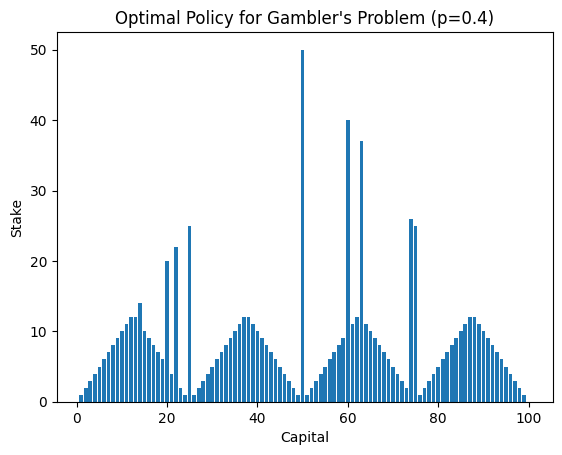

In [36]:
#plot
import matplotlib.pyplot as plt

plt.bar(range(1, len(policy)), policy[1:])
plt.xlabel("Capital")
plt.ylabel("Stake")
plt.title("Optimal Policy for Gambler's Problem (p=0.4)")
plt.show()